In [ ]:
!pip install sdv

import pandas as pd
from google.colab import drive
import os

# Load the dataset
real_data = pd.read_csv("/content/health_disease_prediction.csv")
real_data.head()
#data cleaning
real_data = real_data.drop_duplicates()
real_data = real_data.dropna()

# Label encode categorical columns including goal
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
real_data['Disease'] = label_encoder.fit_transform(real_data['Disease'])  # Target column


#metadata
from sdv.metadata import Metadata
metadata = Metadata.detect_from_dataframe(
    data=real_data,
    table_name='health_disease_prediction'
)

# train TVAE synthesizer
from sdv.single_table import TVAESynthesizer
synthesizer = TVAESynthesizer(metadata)
synthesizer.fit(real_data)

#generate synthetic data
synthetic_data = synthesizer.sample(num_rows=1500)

# split features & goal
X_synthetic = synthetic_data.drop(['Disease'], axis=1)
y_synthetic = synthetic_data['Disease']

X_real = real_data.drop(['Disease'], axis=1)
y_real = real_data['Disease']

# train test split
from sklearn.model_selection import train_test_split
X_train_synthetic, X_test_synthetic, y_train_synthetic, y_test_synthetic = train_test_split(X_synthetic,
                                       y_synthetic,
                                       test_size=0.3,
                                       random_state=42)
X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(X_real, y_real, test_size=0.3, random_state=42)

# feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_real = scaler.fit_transform(X_train_real)
X_test_real = scaler.transform(X_test_real)
X_train_synthetic = scaler.transform(X_train_synthetic)
X_test_synthetic = scaler.transform(X_test_synthetic)

# KNN Model
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_synthetic, y_train_synthetic)

# Predict on real test data
y_pred_knn = knn_model.predict(X_test_real)

# evaluation of KNN
print("\nKNN Classifier Results:")
print(f"Accuracy: {accuracy_score(y_test_real, y_pred_knn):.2f}")
print(f"Precision: {precision_score(y_test_real, y_pred_knn, average='weighted'):.2f}")
print(f"Recall: {recall_score(y_test_real, y_pred_knn, average='weighted'):.2f}")
print(f"F1 Score: {f1_score(y_test_real, y_pred_knn, average='weighted'):.2f}")
# save to CSV
output_dir = '/content/drive/MyDrive/Durgesh(testing)'
os.makedirs(output_dir, exist_ok=True)
synthetic_data.to_csv(f'{output_dir}/synthetic_data_TVAE.csv', index=False)

  Using cached sdv-1.24.1-py3-none-any.whl.metadata (14 kB)
  Using cached boto3-1.39.13-py3-none-any.whl.metadata (6.7 kB)
  Using cached botocore-1.39.13-py3-none-any.whl.metadata (5.7 kB)
  Using cached copulas-0.12.3-py3-none-any.whl.metadata (9.5 kB)
  Using cached ctgan-0.11.0-py3-none-any.whl.metadata (10 kB)
  Using cached deepecho-0.7.0-py3-none-any.whl.metadata (10 kB)
  Using cached rdt-1.17.1-py3-none-any.whl.metadata (10 kB)
  Using cached sdmetrics-0.22.0-py3-none-any.whl.metadata (9.4 kB)
  Using cached s3transfer-0.13.1-py3-none-any.whl.metadata (1.7 kB)
  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusolver_cu12-11.6.1.9-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
Using cached sdv-1.24.1-py3-none-any.whl (183 kB)
Using cached boto3-1.39.13-py3-none-any.whl (139 kB)
Using cached botocore-1.39.13-py3-none-any.whl (13.9 MB)
Using cached copulas-0.12.3-py3-none-any.whl (52 kB)
Using cached ctgan-

/usr/local/lib/python3.11/dist-packages/sdv/single_table/base.py:129: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(



KNN Classifier Results:
Accuracy: 0.70
Precision: 0.49
Recall: 0.70
F1 Score: 0.57


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Preprocessing techniques in knn

In [ ]:
# Hyperparameter tuning
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

k_values = range(1, 16)
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_synthetic, y_train_synthetic)
    y_pred = knn.predict(X_test_real)

    acc = accuracy_score(y_test_real, y_pred)
    f1 = f1_score(y_test_real, y_pred, average='weighted')
    scores.append((k, acc, f1))

# Convert to df for  plotting
scores_df = pd.DataFrame(scores, columns=['k', 'Accuracy', 'F1 Score'])

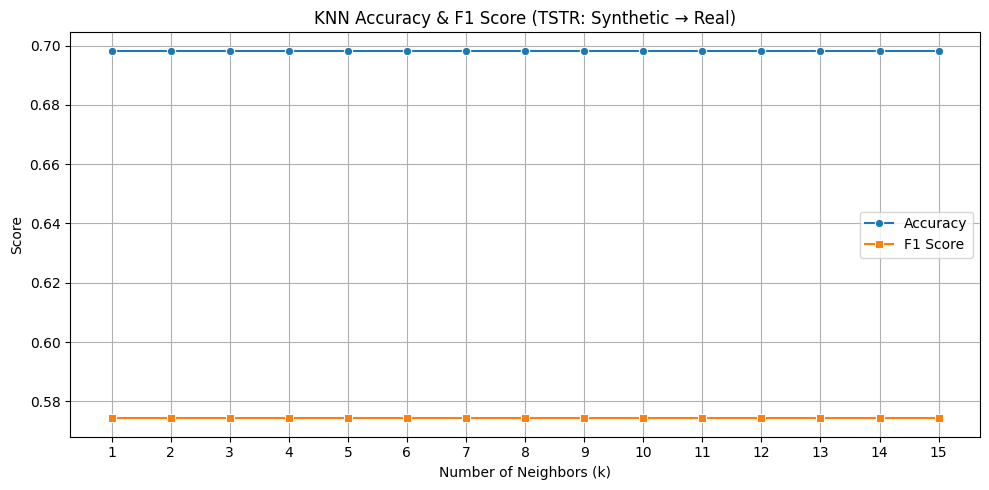

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.lineplot(x='k', y='Accuracy', data=scores_df, marker='o', label='Accuracy')
sns.lineplot(x='k', y='F1 Score', data=scores_df, marker='s', label='F1 Score')
plt.title('KNN Accuracy & F1 Score (TSTR: Synthetic → Real)'\n 'Hyperparameter Tuning')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Score')
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()